#  **Z Score**

## load the placement dataset

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df =pd.read_csv('/content/sample_data/placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [11]:
df.shape

(1000, 3)

## Visualize Data To view outliers

### Scatter plot

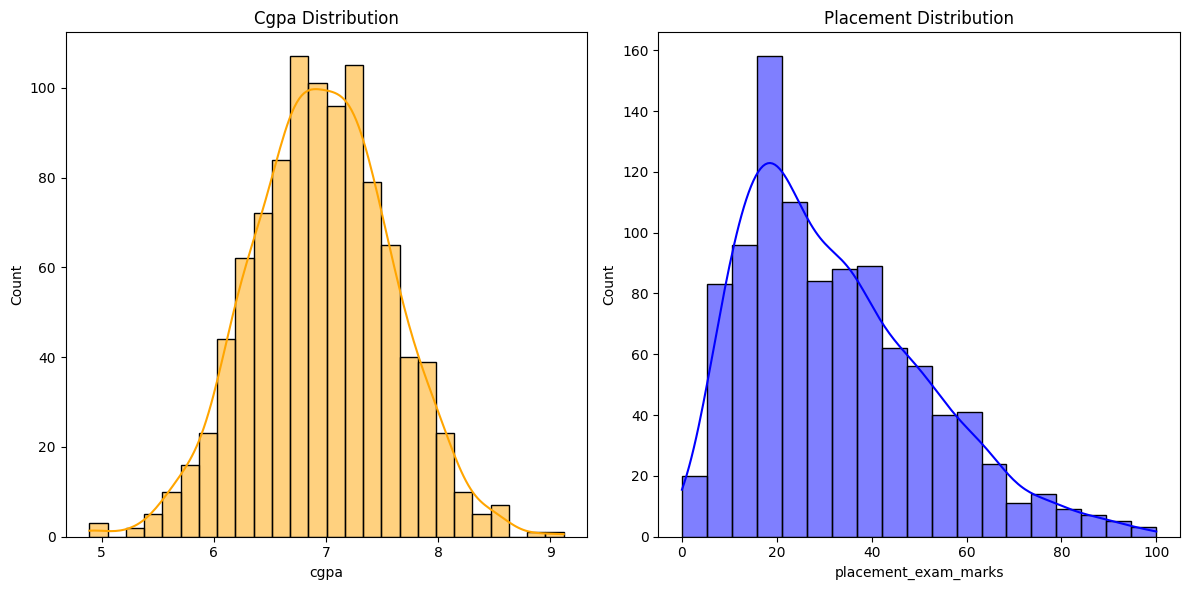

In [13]:
#define figure
plt.figure(figsize=(12,6))

#first sub plot left
plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde=True, color='orange')
plt.title("Cgpa Distribution")

#second sub plot right

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde=True,color='blue')
plt.title("Placement Distribution")

#show plot
plt.tight_layout()
plt.show()

In [15]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

## decision

 > **Here Cgpa is normally distributed but placement marks
 is skewed , so we can aplly z-score only on cgpa bcz it it normally distributed**

## view outliers using boxplots

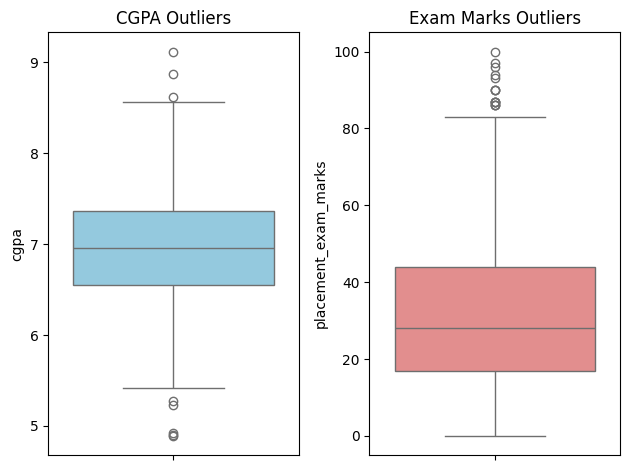

In [14]:
# 2. First plot (Left) - Outliers in CGPA
plt.subplot(1, 2, 1)
sns.boxplot(y=df["cgpa"], color="skyblue")
plt.title("CGPA Outliers")

# 3. Second plot (Right) - Outliers in Exam Marks
plt.subplot(1, 2, 2)
sns.boxplot(y=df["placement_exam_marks"], color="lightcoral")
plt.title("Exam Marks Outliers")

# 4. Show it
plt.tight_layout()
plt.show()

 > In z score mean value is important so view statistical description as the decision making can be easy

In [17]:
df['cgpa'].describe()

,cgpa
count,1000.000000
mean,6.961240
std,0.615898
min,4.890000
25%,6.550000
50%,6.960000
75%,7.370000
max,9.120000


## define boundary

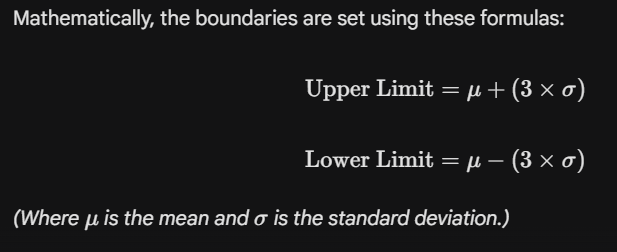

In [19]:
#define threshold
threshold = 3
print(f'highest Value : {df['cgpa'].mean() + (threshold * df['cgpa'].std())}')

print(f'lowest Value : {df['cgpa'].mean() - (threshold * df['cgpa'].std())}')

highest Value : 8.808933625397168
lowest Value : 5.113546374602832


## Finding the outliers

In [20]:
df[(df['cgpa']>8.80) | (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


# Trimming

> Trimming means:
 Removing rows that contain outlier values.

In [22]:
new_df = df[(df['cgpa']>8.80) | (df['cgpa']<5.11)]
new_df.head(10)

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


Text(0.5, 1.0, 'CGPA Outliers')

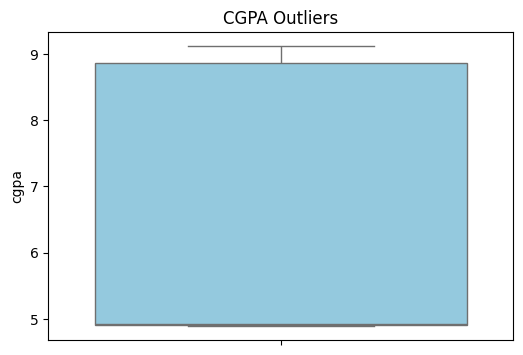

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(y=new_df["cgpa"], color="skyblue")
plt.title("CGPA Outliers")

  > No outliers

# Trimming with Z Score

In [27]:
# Calculating the Zscore

df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()
df.head(7)

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
5,7.30,23.0,1,0.550026
6,6.69,11.0,0,-0.440398


In [28]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [29]:
# Trimming
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


# Capping

## define limit

In [30]:
threshold = 3
print(f'highest Value : {df['cgpa'].mean() + (threshold * df['cgpa'].std())}')

print(f'lowest Value : {df['cgpa'].mean() - (threshold * df['cgpa'].std())}')

highest Value : 8.808933625397168
lowest Value : 5.113546374602832


## Replace oulier with up & low values

In [37]:
highest_Value = 8.808933625397168
lowest_Value = 5.113546374602832

In [38]:
df['cgpa'] = np.where(
    df['cgpa']>highest_Value,
    highest_Value,
    np.where(
        df['cgpa']<lowest_Value,
        lowest_Value,
        df['cgpa']
    )
)

In [39]:
df.shape

(1000, 4)

In [40]:
df['cgpa'].describe()

,cgpa
count,1000.000000
mean,6.961499
std,0.612688
min,5.113546
25%,6.550000
50%,6.960000
75%,7.370000
max,8.808934
